# Change Detection Task (CDT) Analysis

This notebook analyzes CDT data from both datapruebas and neuropruebas sources.

## Usage
There are two ways to use this notebook:

1. **Load existing analysis** (fast): Use `get_latest_cdt_analysis()` to load pre-computed results
2. **Run fresh analysis** (slow): Execute the full pipeline with `load_cdt_analysis()`

To run the analysis from command line:
```bash
python -m src.loader.cdt_analysis_loader
```

## Metrics computed:
- **K_4, K_6**: Cowan's K (working memory capacity for 4 and 6 items)
- **accuracy**: Proportion of correct responses
- **media_rt, mediana_rt**: Mean and median response times
- **trials_no_contestados**: Number of unanswered trials


In [1]:
import os
import sys

# Add project root to path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.analysis import ChangeDetectionTask
from src.loader import load_cdt_experiment, load_cdt_analysis, get_latest_cdt_analysis
from src import config

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline


## 1. Load Data

**Option A**: Load latest pre-computed analysis (fast)


In [2]:
# Load latest pre-computed analysis
result = get_latest_cdt_analysis()

if result is not None:
    df_cdt_all, run_config = result
    print(f"Loaded analysis from: {run_config.get('timestamp', 'unknown')}")
    print(f"Total subjects: {len(df_cdt_all)}")
    
    # Split by origin for compatibility with rest of notebook
    df_cdt_datapruebas = df_cdt_all[df_cdt_all["origin"] == "datapruebas"].copy()
    df_cdt_neuropruebas = df_cdt_all[df_cdt_all["origin"] == "neuropruebas"].copy()
    print(f"  - Datapruebas: {len(df_cdt_datapruebas)}")
    print(f"  - Neuropruebas: {len(df_cdt_neuropruebas)}")
else:
    print("No pre-computed analysis found. Run Option B below or execute:")
    print("  python -m src.loader.cdt_analysis_loader")


Loaded analysis from: 2026-01-12_12-05-11
Total subjects: 248
  - Datapruebas: 45
  - Neuropruebas: 203


**Option B**: Run fresh analysis (slow, use if no pre-computed data exists)


In [3]:
# SKIP THIS CELL if you already loaded data in Option A
# Uncomment and run only if you need fresh analysis

# df_cdt_all, save_path = load_cdt_analysis(save_results=True)
# df_cdt_datapruebas = df_cdt_all[df_cdt_all["origin"] == "datapruebas"].copy()
# df_cdt_neuropruebas = df_cdt_all[df_cdt_all["origin"] == "neuropruebas"].copy()
# print(f"Analysis complete. Saved to: {save_path}")


## 2. Data Overview


In [4]:
# Quick view of the data
print(f"Total subjects: {len(df_cdt_all)}")
print(f"Columns: {list(df_cdt_all.columns)}")
df_cdt_all.head(10)


Total subjects: 248
Columns: ['subject_id', 'media_rt', 'mediana_rt', 'trials_no_contestados', 'accuracy', 'accuracy_4', 'accuracy_6', 'K_4', 'K_6', 'n_trials_4', 'n_trials_6', 'view_dist_cm', 'origin']


,subject_id,media_rt,mediana_rt,trials_no_contestados,accuracy,accuracy_4,accuracy_6,K_4,K_6,n_trials_4,n_trials_6,view_dist_cm,origin
0,b658934b-1bbc-4897-a989-1827a61cfb03,1328.58,1137.70,1,0.68,0.75,0.61,2.00,1.32,60,60,51.64,datapruebas
1,4ba9507b-7579-4553-bc1c-d65cdb304613,819.65,750.95,0,0.81,0.88,0.73,3.07,2.80,60,60,40.49,datapruebas
2,5c1c9209-2512-44b9-8686-4778e212299e,1310.62,1102.70,2,0.75,0.88,0.63,3.05,1.53,60,60,45.21,datapruebas
3,7d540a4e-9e01-472d-93aa-37f42cbfc693,803.29,758.40,0,0.70,0.85,0.55,2.80,0.60,60,60,48.70,datapruebas
4,a31fee9a-3e68-4347-925c-cdc898edfc3f,1167.47,1033.00,0,0.80,0.87,0.73,2.93,2.80,60,60,50.42,datapruebas
5,3f45b93b-b0e2-427d-a081-40a19722db2f,1350.73,1130.10,1,0.89,0.92,0.87,3.32,4.40,60,60,48.56,datapruebas
6,39675e5b-4e50-4bb2-9764-e434c64b3b8a,596.05,553.50,0,0.90,1.00,0.80,4.00,3.60,60,60,47.60,datapruebas
7,d82cfda0-f10e-4619-bff0-d78b387387f5,1133.70,1111.50,0,0.76,0.78,0.73,2.27,2.80,60,60,54.95,datapruebas
8,a740ac85-3681-4e14-a510-43c23a09286b,624.06,602.95,0,0.63,0.68,0.58,1.47,1.00,60,60,48.44,datapruebas
9,86473a14-8eee-4f2d-9198-1b93c07da896,904.41,778.40,0,0.77,0.85,0.68,2.80,2.20,60,60,57.00,datapruebas


## 3. Descriptive Statistics


In [5]:
# Summary statistics by origin
metrics_cols = ["K_4", "K_6", "accuracy", "accuracy_4", "accuracy_6", "media_rt", "mediana_rt", "trials_no_contestados"]
available_cols = [c for c in metrics_cols if c in df_cdt_all.columns]
df_cdt_all.groupby("origin")[available_cols].describe().T


origin                       datapruebas  neuropruebas
K_4                   count    45.000000    203.000000
                      mean      2.843778      2.824975
                      std       0.590409      0.614713
                      min       1.330000      0.530000
                      25%       2.670000      2.400000
...                                  ...           ...
trials_no_contestados min       0.000000      0.000000
                      25%       0.000000      0.000000
                      50%       0.000000      0.000000
                      75%       0.000000      0.000000
                      max       2.000000     10.000000

[64 rows x 2 columns]

In [6]:
# Cowan's K descriptive stats
print("Cowan's K Statistics by Origin:")
print("=" * 40)
print("\nDatapruebas:")
print(f"K_4: mean={df_cdt_datapruebas['K_4'].mean():.2f}, SD={df_cdt_datapruebas['K_4'].std():.2f}")
print(f"K_6: mean={df_cdt_datapruebas['K_6'].mean():.2f}, SD={df_cdt_datapruebas['K_6'].std():.2f}")
print("\nNeuropruebas:")
print(f"K_4: mean={df_cdt_neuropruebas['K_4'].mean():.2f}, SD={df_cdt_neuropruebas['K_4'].std():.2f}")
print(f"K_6: mean={df_cdt_neuropruebas['K_6'].mean():.2f}, SD={df_cdt_neuropruebas['K_6'].std():.2f}")


Cowan's K Statistics by Origin:

Datapruebas:
K_4: mean=2.84, SD=0.59
K_6: mean=2.39, SD=0.95

Neuropruebas:
K_4: mean=2.82, SD=0.61
K_6: mean=2.46, SD=1.02


## 4. Cowan's K Distribution


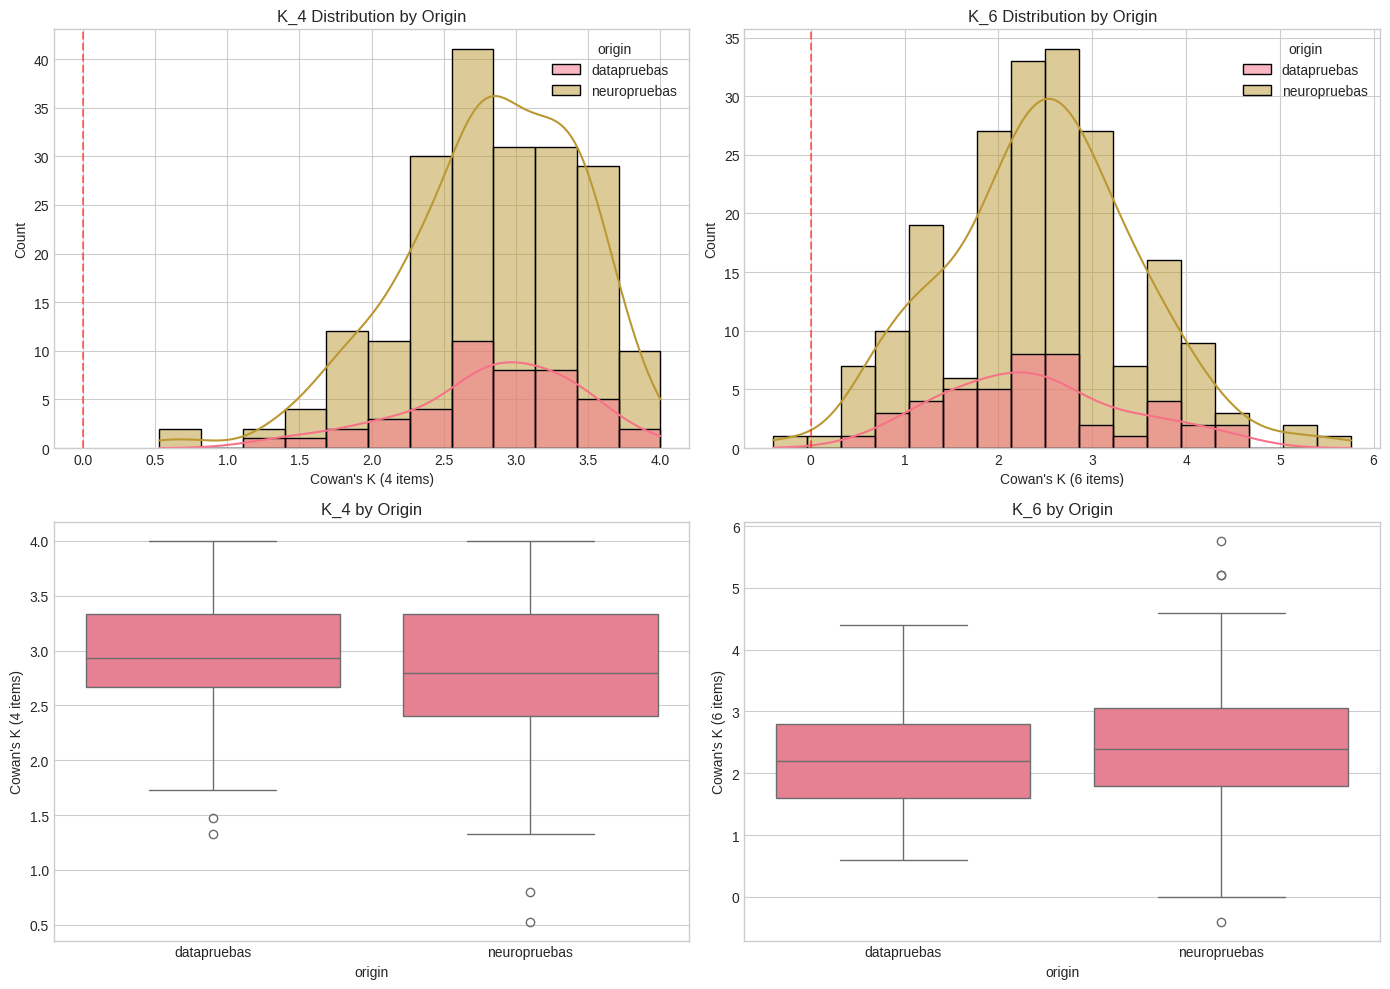

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# K_4 histogram
ax1 = axes[0, 0]
sns.histplot(data=df_cdt_all, x="K_4", hue="origin", kde=True, ax=ax1)
ax1.set_title("K_4 Distribution by Origin")
ax1.set_xlabel("Cowan's K (4 items)")
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Zero line')

# K_6 histogram
ax2 = axes[0, 1]
sns.histplot(data=df_cdt_all, x="K_6", hue="origin", kde=True, ax=ax2)
ax2.set_title("K_6 Distribution by Origin")
ax2.set_xlabel("Cowan's K (6 items)")
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Zero line')

# K_4 box plot
ax3 = axes[1, 0]
sns.boxplot(data=df_cdt_all, x="origin", y="K_4", ax=ax3)
ax3.set_title("K_4 by Origin")
ax3.set_ylabel("Cowan's K (4 items)")

# K_6 box plot
ax4 = axes[1, 1]
sns.boxplot(data=df_cdt_all, x="origin", y="K_6", ax=ax4)
ax4.set_title("K_6 by Origin")
ax4.set_ylabel("Cowan's K (6 items)")

plt.tight_layout()
plt.show()


## 5. Correlation between K_4 and K_6


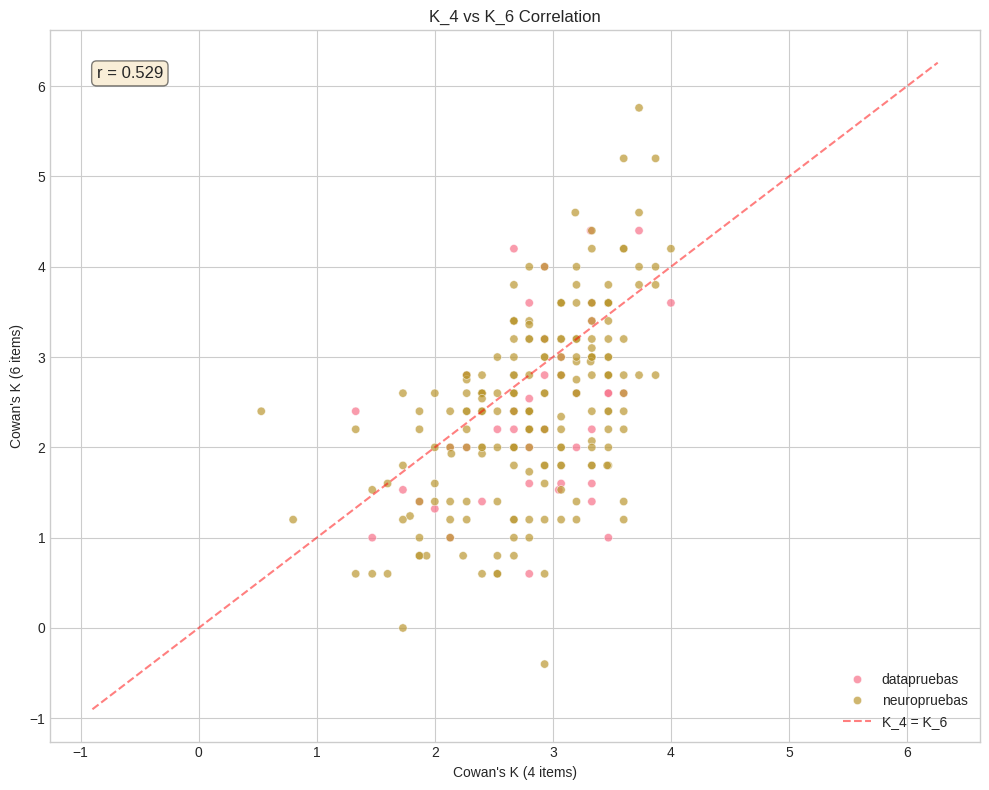

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=df_cdt_all,
    x="K_4",
    y="K_6",
    hue="origin",
    alpha=0.7,
    ax=ax
)

# Add diagonal line
lims = [min(df_cdt_all["K_4"].min(), df_cdt_all["K_6"].min()) - 0.5,
        max(df_cdt_all["K_4"].max(), df_cdt_all["K_6"].max()) + 0.5]
ax.plot(lims, lims, 'r--', alpha=0.5, label='K_4 = K_6')

ax.set_xlabel("Cowan's K (4 items)")
ax.set_ylabel("Cowan's K (6 items)")
ax.set_title("K_4 vs K_6 Correlation")
ax.legend()

# Calculate correlation
corr = df_cdt_all["K_4"].corr(df_cdt_all["K_6"])
ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## 6. Quality Control Checks

Identifying potentially invalid data based on common CDT quality criteria.


In [9]:
# Check for negative K values (indicates chance-level or worse performance)
negative_k4 = df_cdt_all[df_cdt_all["K_4"] < 0]
negative_k6 = df_cdt_all[df_cdt_all["K_6"] < 0]
print(f"Subjects with negative K_4: {len(negative_k4)}")
print(f"Subjects with negative K_6: {len(negative_k6)}")


Subjects with negative K_4: 0
Subjects with negative K_6: 1


In [10]:
# Check for very low accuracy (below chance = 0.5)
low_accuracy = df_cdt_all[df_cdt_all["accuracy"] < 0.5]
print(f"Subjects with accuracy below chance (<0.5): {len(low_accuracy)}")
if len(low_accuracy) > 0:
    display(low_accuracy[["subject_id", "origin", "accuracy", "K_4", "K_6", "trials_no_contestados"]])


Subjects with accuracy below chance (<0.5): 0


In [11]:
# Check for high number of unanswered trials
high_no_response = df_cdt_all[df_cdt_all["trials_no_contestados"] > 10]
print(f"Subjects with >10 unanswered trials: {len(high_no_response)}")
if len(high_no_response) > 0:
    display(high_no_response[["subject_id", "origin", "trials_no_contestados", "accuracy", "K_4", "K_6"]].sort_values("trials_no_contestados", ascending=False))


Subjects with >10 unanswered trials: 0


## 7. Accuracy Distribution


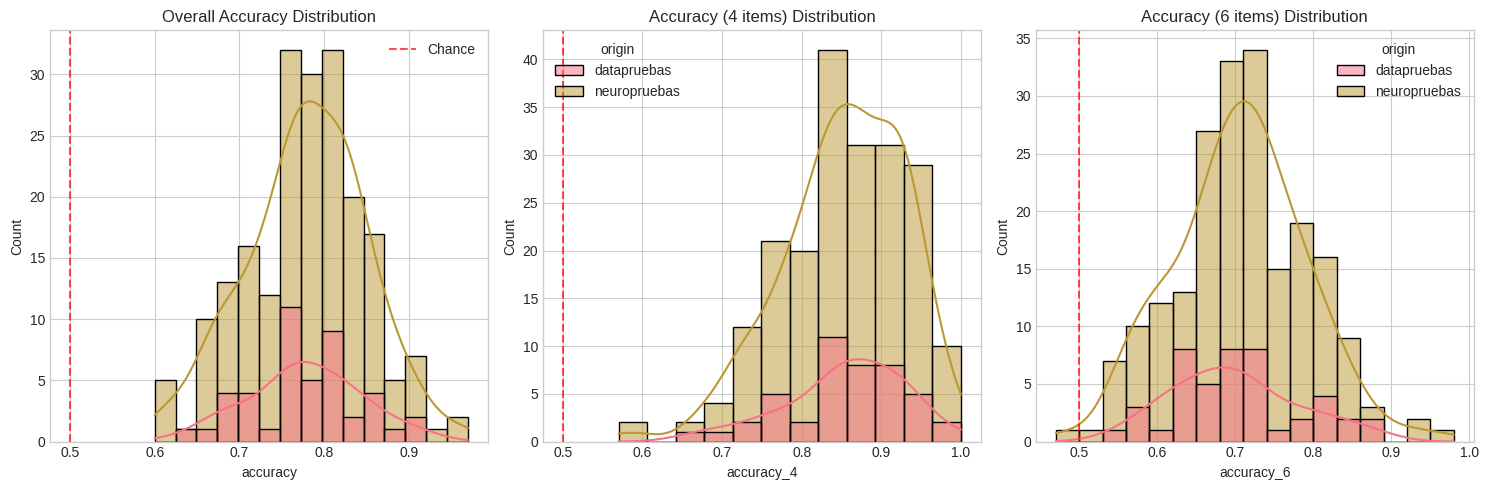

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall accuracy
ax1 = axes[0]
sns.histplot(data=df_cdt_all, x="accuracy", hue="origin", kde=True, ax=ax1)
ax1.set_title("Overall Accuracy Distribution")
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Chance')
ax1.legend()

# Accuracy_4
ax2 = axes[1]
if "accuracy_4" in df_cdt_all.columns:
    sns.histplot(data=df_cdt_all, x="accuracy_4", hue="origin", kde=True, ax=ax2)
    ax2.set_title("Accuracy (4 items) Distribution")
    ax2.axvline(x=0.5, color='red', linestyle='--', alpha=0.7)

# Accuracy_6
ax3 = axes[2]
if "accuracy_6" in df_cdt_all.columns:
    sns.histplot(data=df_cdt_all, x="accuracy_6", hue="origin", kde=True, ax=ax3)
    ax3.set_title("Accuracy (6 items) Distribution")
    ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 8. Response Time Analysis


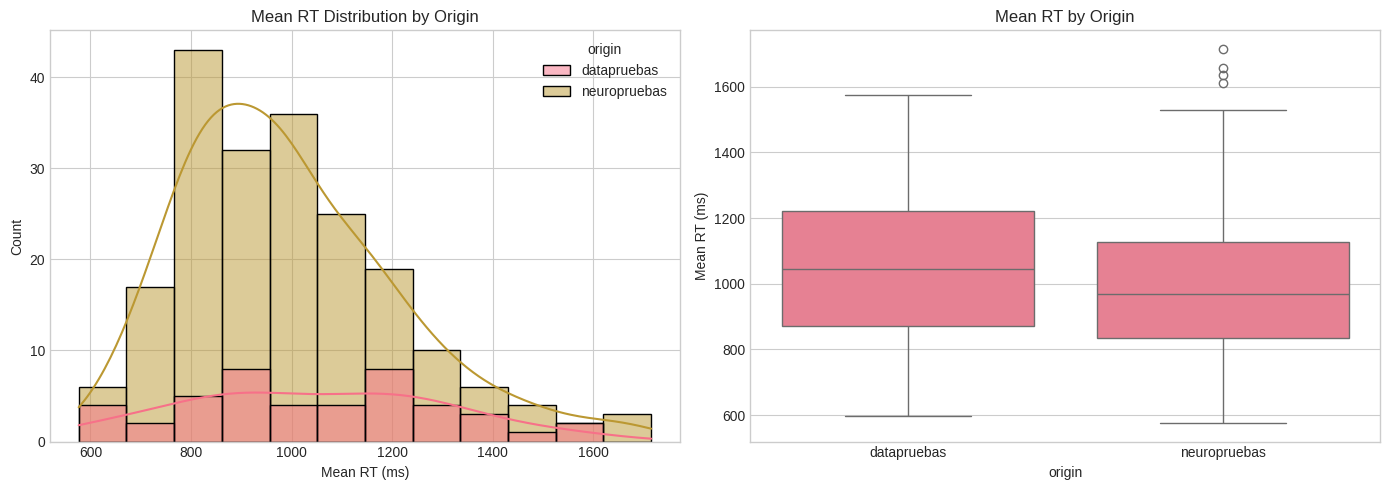

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RT histogram
ax1 = axes[0]
sns.histplot(data=df_cdt_all, x="media_rt", hue="origin", kde=True, ax=ax1)
ax1.set_title("Mean RT Distribution by Origin")
ax1.set_xlabel("Mean RT (ms)")

# RT box plot
ax2 = axes[1]
sns.boxplot(data=df_cdt_all, x="origin", y="media_rt", ax=ax2)
ax2.set_title("Mean RT by Origin")
ax2.set_ylabel("Mean RT (ms)")

plt.tight_layout()
plt.show()


## 9. Re-run and Save Results (Optional)

If you made changes to the analysis or want to create a new timestamped run:


In [14]:
# Uncomment to run fresh analysis and save results
# This will create a new timestamped folder with results

# df_cdt_all, save_path = load_cdt_analysis(save_results=True)
# print(f"Results saved to: {save_path}")

# Or run from command line:
# !python -m src.loader.cdt_analysis_loader


## 10. Summary

Key findings from CDT analysis:


In [15]:
print("CDT Analysis Summary")
print("=" * 50)
print(f"\nTotal subjects analyzed: {len(df_cdt_all)}")
print(f"  - Datapruebas: {len(df_cdt_datapruebas)}")
print(f"  - Neuropruebas: {len(df_cdt_neuropruebas)}")
print(f"\nCowan's K (Working Memory Capacity):")
print(f"  K_4: mean={df_cdt_all['K_4'].mean():.2f} (SD={df_cdt_all['K_4'].std():.2f})")
print(f"  K_6: mean={df_cdt_all['K_6'].mean():.2f} (SD={df_cdt_all['K_6'].std():.2f})")
print(f"\nMean accuracy: {df_cdt_all['accuracy'].mean():.2f}")
print(f"\nPotential quality issues:")
print(f"  - Negative K_4: {len(negative_k4)} subjects")
print(f"  - Negative K_6: {len(negative_k6)} subjects")
print(f"  - Low accuracy (<0.5): {len(low_accuracy)} subjects")
print(f"  - High no-response (>10): {len(high_no_response)} subjects")


CDT Analysis Summary

Total subjects analyzed: 248
  - Datapruebas: 45
  - Neuropruebas: 203

Cowan's K (Working Memory Capacity):
  K_4: mean=2.83 (SD=0.61)
  K_6: mean=2.45 (SD=1.00)

Mean accuracy: 0.78

Potential quality issues:
  - Negative K_4: 0 subjects
  - Negative K_6: 1 subjects
  - Low accuracy (<0.5): 0 subjects
  - High no-response (>10): 0 subjects


/tmp/ipykernel_483977/2787644080.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


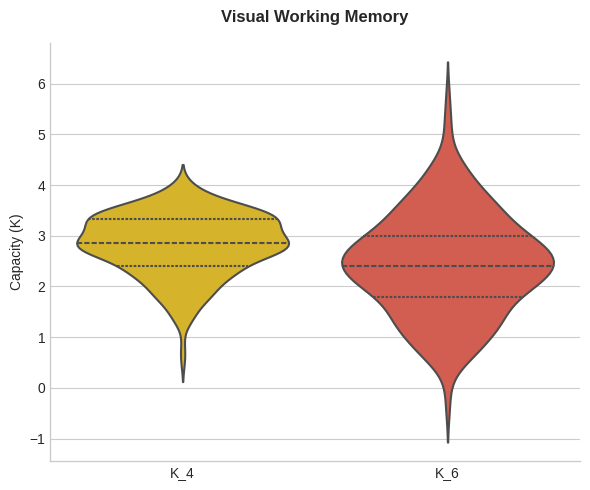

In [27]:
df_plot_cdt = df_cdt_all[['K_4', 'K_6']].melt(var_name='Load', value_name='K')


plt.figure(figsize=(6, 5))
sns.violinplot(
    data=df_plot_cdt, 
    x='Load', 
    y='K', 
    palette=['#f1c40f', '#e74c3c'], 
    inner="quartile", 
    linewidth=1.5
)
plt.title('Visual Working Memory', fontweight='bold', pad=15)
plt.ylabel('Capacity (K)')
plt.xlabel('')
sns.despine()
plt.tight_layout()
# plt.savefig('Figure_2D_CDT.png', dpi=300)
plt.show()